
Small Project
>

Brist Cancer


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
data=load_breast_cancer()
X=data.data
y=data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [ ]:

models ={
    "Linear" : SVC(kernel='linear'),
    "Polynomial" : SVC(kernel='poly'),
    "RBF" : SVC(kernel='rbf'),
    "Sigmoid" : SVC(kernel='sigmoid')
}
results=[]

for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)

  acc=accuracy_score(y_test,y_pred)
  cm=confusion_matrix(y_test,y_pred)
  cr=classification_report(y_test,y_pred)

  results.append({
      'Model':name,
      'Accuracy':acc,
      'Confusion Matrix':cm,
      'Classification Report':cr
  })

for result in results:
    print(f"\nModel: {result['Model']}")
    print(f"Accuracy: {result['Accuracy']:.4f}")
    print("Confusion Matrix:")
    print(result['Confusion Matrix'])
    print("Classification Report:")
    print(result['Classification Report'])


Model: Linear
Accuracy: 0.9561
Confusion Matrix:
[[39  4]
 [ 1 70]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Model: Polynomial
Accuracy: 0.9474
Confusion Matrix:
[[37  6]
 [ 0 71]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


Model: RBF
Accuracy: 0.9474
Confusion Matrix:
[[37  6]
 [ 0 71]]
Classification Report:
              precision    recall  f1-score   support

           0  

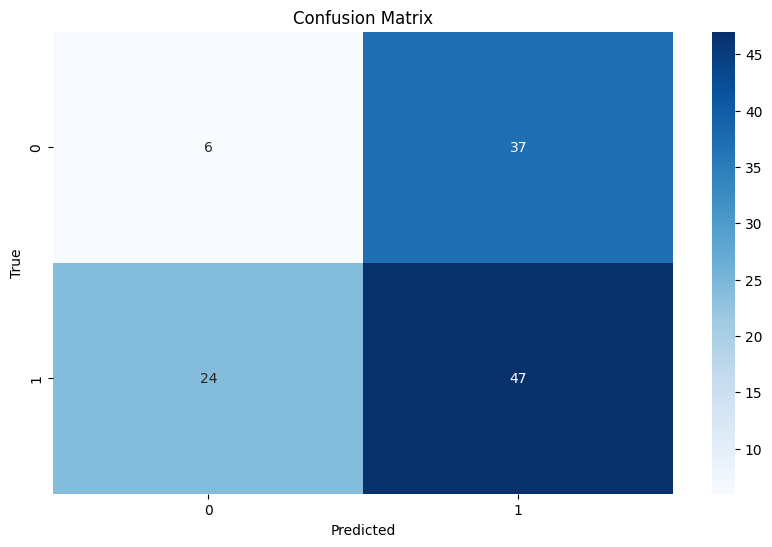

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Credit Card fruad Prediction


In [ ]:
df=pd.read_csv('/content/creditcard.csv')

In [ ]:
df.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11959 entries, 0 to 11958
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11959 non-null  int64  
 1   V1      11959 non-null  float64
 2   V2      11959 non-null  float64
 3   V3      11959 non-null  float64
 4   V4      11959 non-null  float64
 5   V5      11959 non-null  float64
 6   V6      11959 non-null  float64
 7   V7      11959 non-null  float64
 8   V8      11959 non-null  float64
 9   V9      11959 non-null  float64
 10  V10     11959 non-null  float64
 11  V11     11959 non-null  float64
 12  V12     11959 non-null  float64
 13  V13     11959 non-null  float64
 14  V14     11959 non-null  float64
 15  V15     11959 non-null  float64
 16  V16     11959 non-null  float64
 17  V17     11959 non-null  float64
 18  V18     11959 non-null  float64
 19  V19     11959 non-null  float64
 20  V20     11958 non-null  float64
 21  V21     11958 non-null  float64
 22

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]


,0
V20,1
V21,1
V22,1
V23,1
V24,1
V25,1
V26,1
V27,1
V28,1
Amount,1


In [ ]:
df.fillna(df.median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,...,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000
mean,8009.996822,-0.216230,0.277097,0.889505,0.282606,-0.086585,0.139986,-0.121943,-0.048727,0.911579,...,-0.061480,-0.153848,-0.033710,0.017118,0.104797,0.062886,0.008319,0.000273,62.348737,0.004348
std,6204.332248,1.583914,1.308884,1.331824,1.478162,1.191776,1.306285,1.153899,1.246823,1.192349,...,0.918667,0.626605,0.505334,0.591370,0.429396,0.561580,0.405083,0.261220,178.240062,0.065800
min,0.000000,-27.670569,-34.607649,-22.804686,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-7.175097,...,-11.468435,-8.593642,-19.254328,-2.512377,-4.781606,-1.338556,-7.976100,-3.575312,0.000000,0.000000
25%,2542.000000,-0.978944,-0.261503,0.417186,-0.622456,-0.688114,-0.622521,-0.591335,-0.185243,0.196741,...,-0.268135,-0.543611,-0.171826,-0.333251,-0.144000,-0.353853,-0.080063,-0.015459,5.000000,0.000000
50%,6662.000000,-0.340742,0.256346,0.951223,0.213029,-0.183847,-0.146903,-0.094876,0.013616,0.894911,...,-0.130062,-0.124900,-0.044299,0.072099,0.143136,0.001972,-0.003039,0.015452,15.950000,0.000000
75%,12382.000000,1.161273,0.883626,1.613678,1.159141,0.346298,0.508432,0.431657,0.267560,1.589120,...,0.021687,0.234028,0.075671,0.401765,0.380062,0.409187,0.106307,0.073161,50.000000,0.000000
max,20642.000000,1.960497,9.092123,4.101716,11.927512,34.099309,21.393069,34.303177,5.499963,10.392889,...,22.614889,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


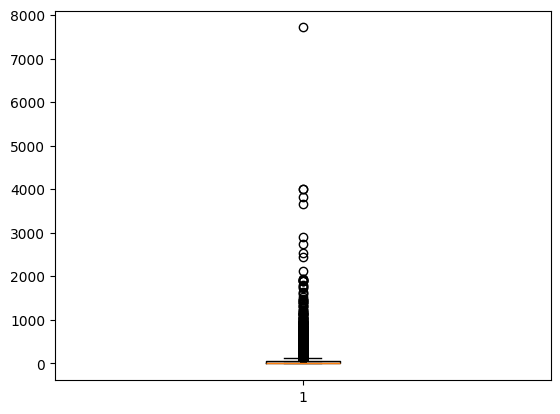

In [ ]:
plt.boxplot(df['Amount'])
plt.show()

In [ ]:
X=df.drop('Class',axis=1)
y=df['Class']

In [ ]:
import pandas as pd

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print(outliers.sum())

Time         0
V1         257
V2         611
V3         399
V4         158
V5         773
V6        1084
V7         329
V8        1230
V9         279
V10        633
V11         69
V12         54
V13         32
V14        265
V15        190
V16        205
V17        281
V18        430
V19        272
V20       1126
V21        898
V22        165
V23        819
V24        181
V25        275
V26         13
V27       1380
V28       2197
Amount    1495
Class       52
dtype: int64


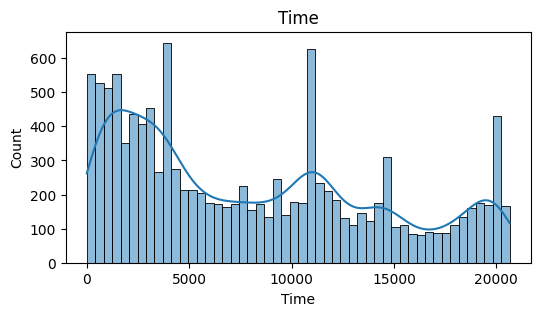

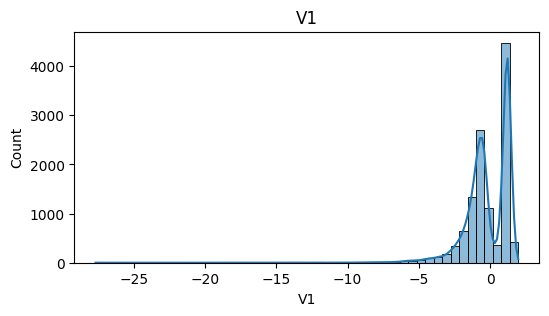

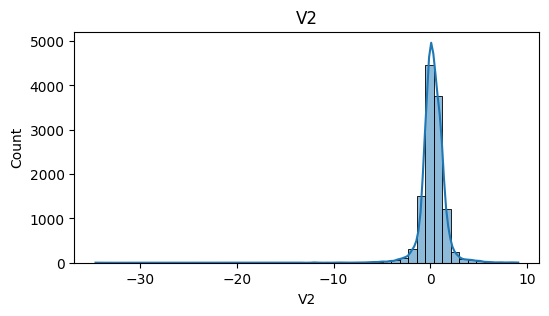

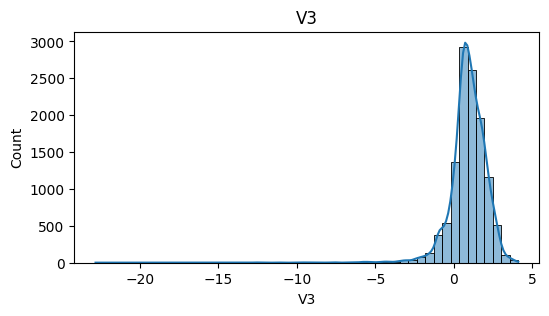

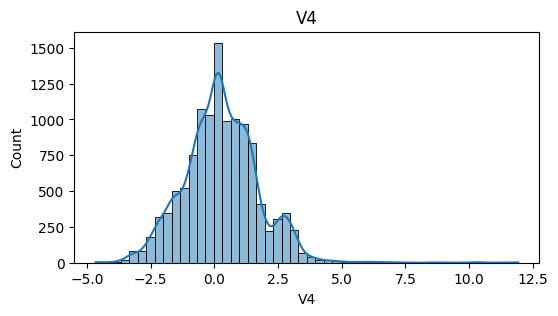

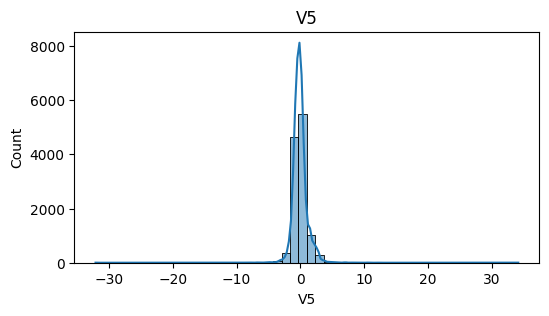

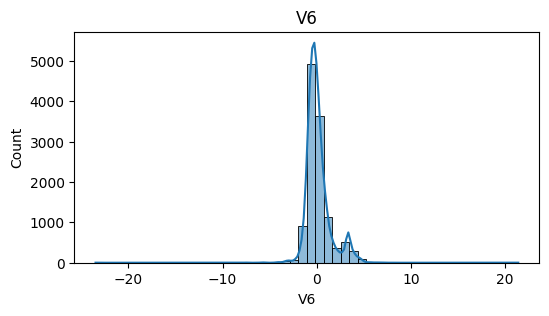

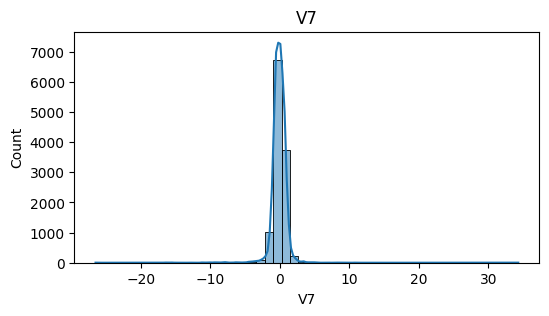

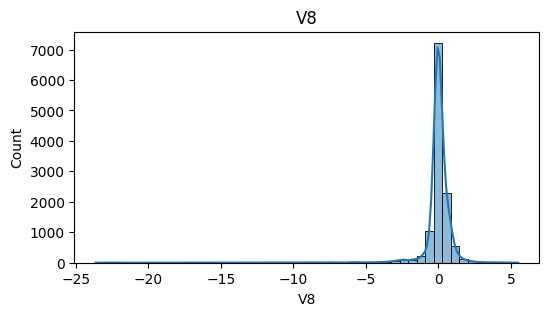

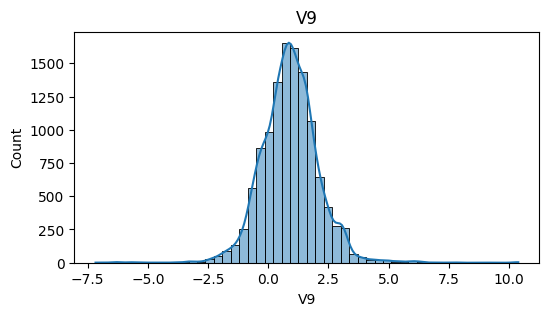

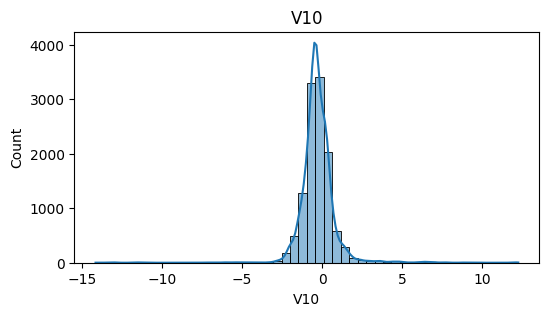

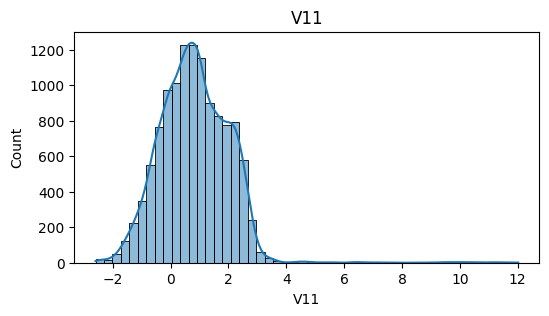

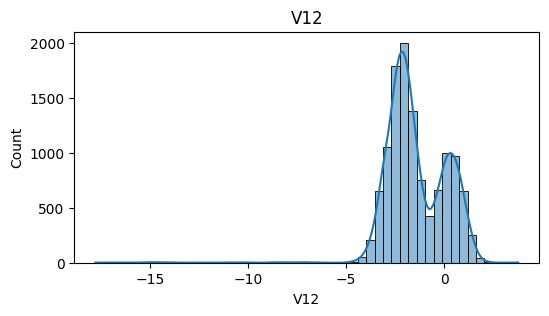

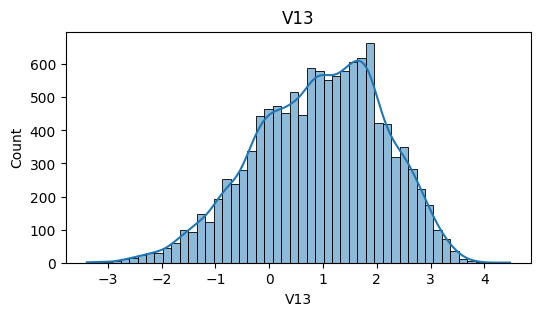

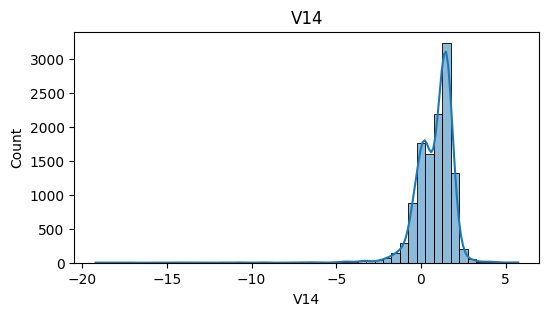

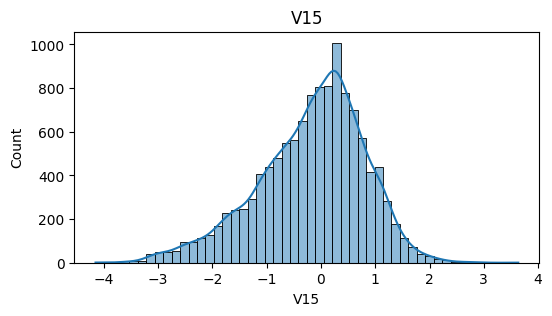

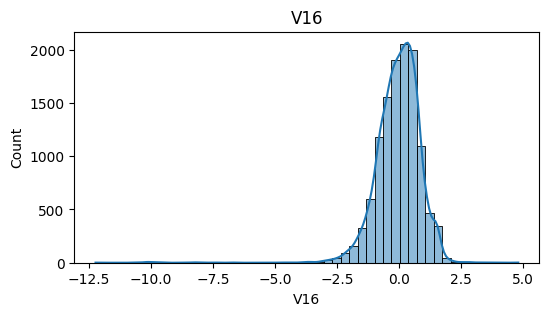

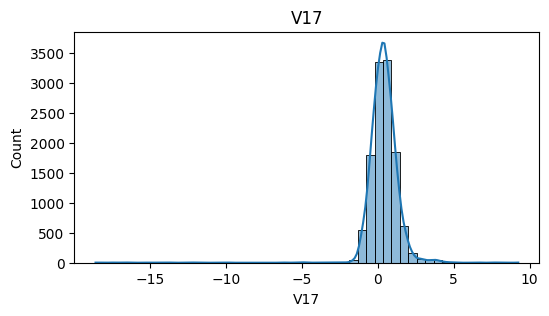

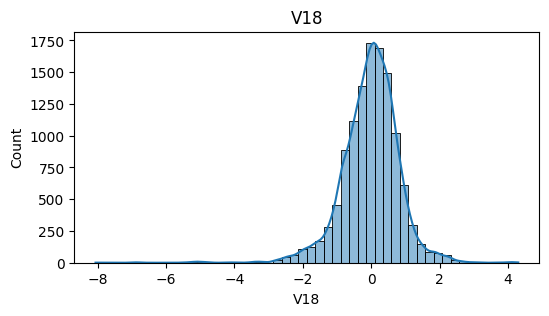

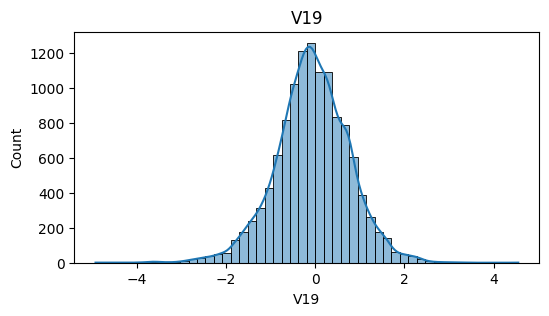

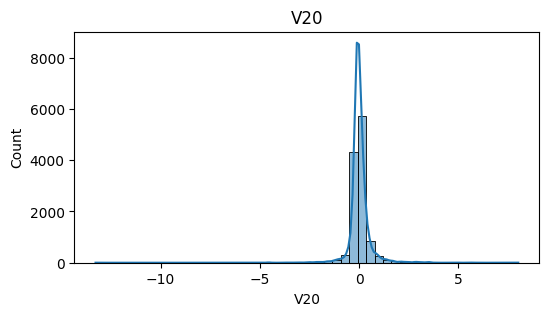

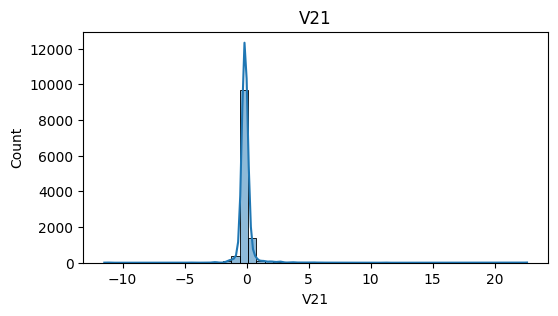

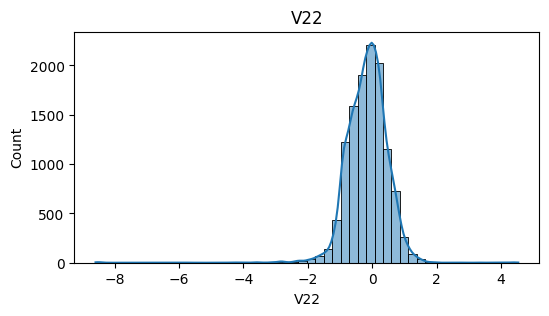

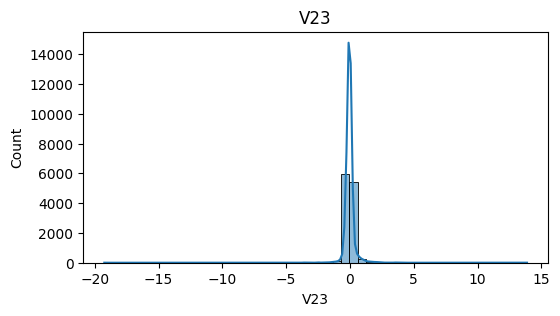

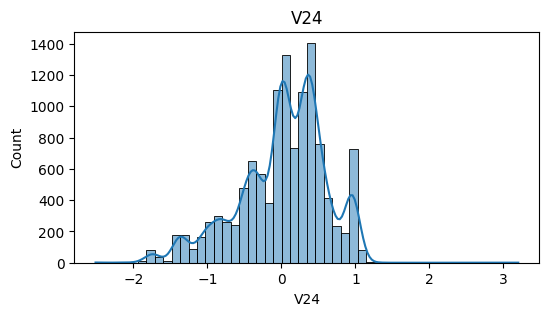

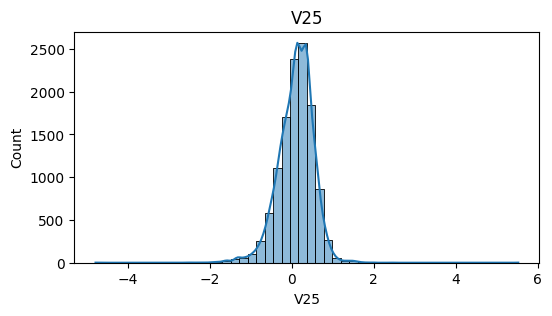

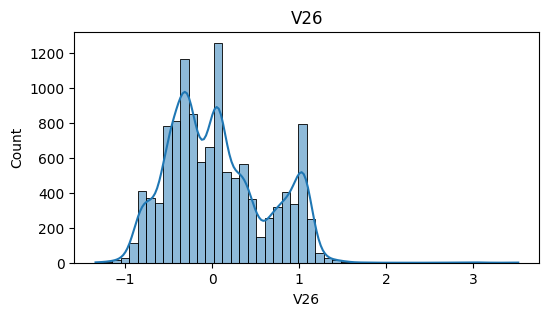

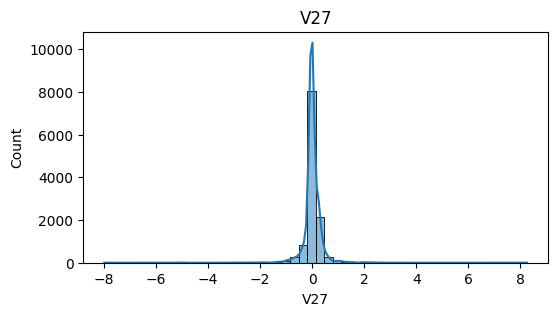

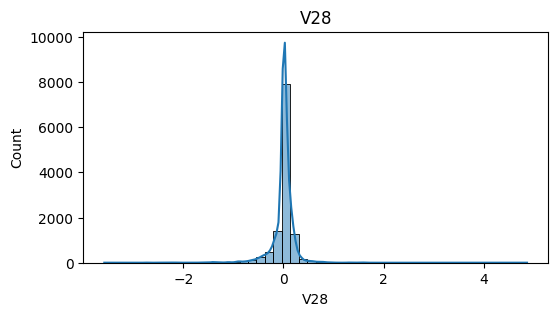

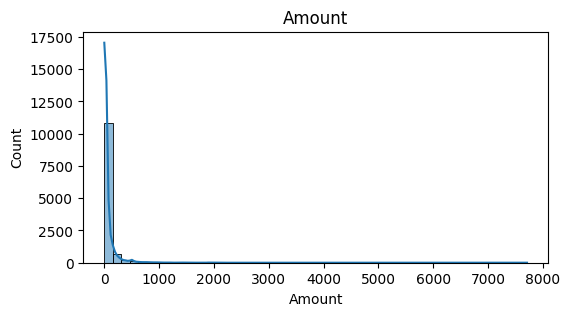

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = df.columns.drop("Class")

for i, col in enumerate(cols):
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(col)
    plt.show()

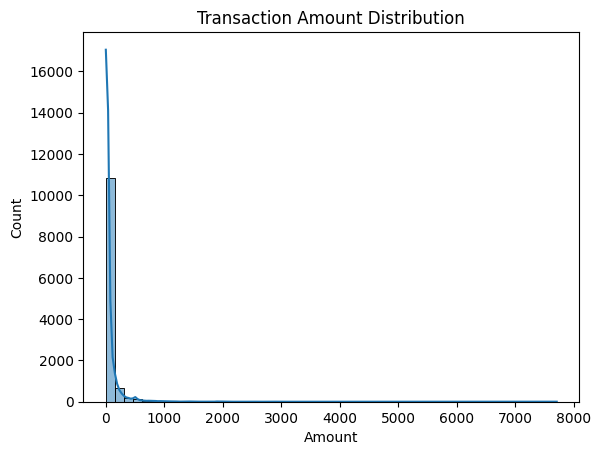

In [ ]:
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
import pandas as pd

df_clipped = df.copy()

for col in df.columns:

    if col != "Class":  # Target variable ko skip karo

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clipped[col] = df_clipped[col].clip(lower, upper)

print("Clipping Complete")

Clipping Complete


In [ ]:
print(df["Amount"].describe())
print(df_clipped["Amount"].describe())

count    11959.000000
mean        62.348737
std        178.240062
min          0.000000
25%          5.000000
50%         15.950000
75%         50.000000
max       7712.430000
Name: Amount, dtype: float64
count    11959.000000
mean        34.568300
std         39.574707
min          0.000000
25%          5.000000
50%         15.950000
75%         50.000000
max        117.500000
Name: Amount, dtype: float64


In [ ]:
import numpy as np

df["Hour"] = (df["Time"] / 3600) % 24 # Convert elapsed time (seconds) to a 24-hour cycle
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

In [ ]:
X = df.drop(["Class", "Time"], axis=1)
y = df["Class"]

In [ ]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,Hour,Hour_sin,Hour_cos
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.000000,0.000000,1.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.000000,0.000000,1.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.000278,0.000073,1.000000
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.000278,0.000073,1.000000
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.000556,0.000145,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11954,1.504204,-0.411728,0.200090,-0.778753,-0.442232,-0.119677,-0.782660,-0.165178,0.691819,0.247322,...,-0.143260,-1.057332,0.529188,-0.235062,-0.012089,0.000905,9.00,5.730833,0.997518,0.070409
11955,1.134994,0.096340,0.277921,0.319692,0.742800,1.611803,-0.458649,0.390012,1.424541,-0.656249,...,0.222256,-1.859104,-0.109777,0.279049,0.012398,-0.009090,0.99,5.732222,0.997544,0.070047
11956,-6.305012,3.944886,-4.707362,1.539602,-3.934785,-1.730565,-2.104936,3.843447,0.863458,0.255574,...,-0.108896,0.691434,-0.261979,-0.447540,0.212900,-0.031021,89.99,5.732778,0.997554,0.069902
11957,1.161960,-0.398297,1.123732,-0.474237,-1.226667,-0.519325,-0.804179,0.070134,3.262926,-1.464389,...,0.050903,0.330479,0.315692,-0.712765,0.073836,0.028055,11.85,5.732778,0.997554,0.069902


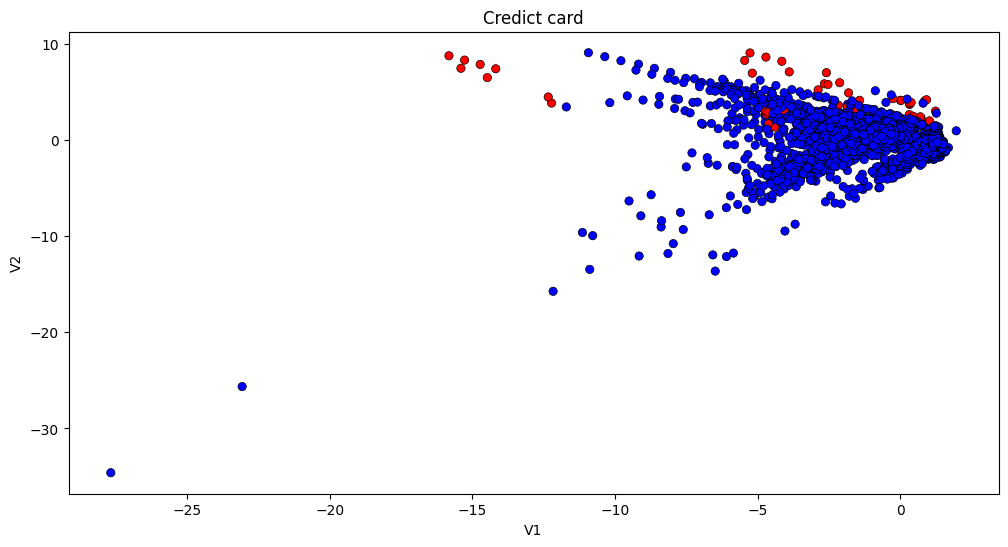

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], c=y, cmap='bwr', edgecolors='k')
plt.title('Credict card')
plt.show()

In [ ]:
kernals={
    "Linear" : SVC(kernel='linear'),
    "Polynomial" : SVC(kernel='poly'),
    "RBF" : SVC(kernel='rbf'),
    "Sigmoid" : SVC(kernel='sigmoid')
}
for name,model in kernals.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  acc=accuracy_score(y_test,y_pred)
  cm=confusion_matrix(y_test,y_pred)
  cr=classification_report(y_test,y_pred)
  print(f"\nModel: {name}")
  print(f"Accuracy: {acc:.4f}")
  # print("Confusion Matrix:")
  # print(cm)
  # print("Classification Report:")
  # print(cr)




Model: Linear
Accuracy: 0.9561

Model: Polynomial
Accuracy: 0.9474

Model: RBF
Accuracy: 0.9474

Model: Sigmoid
Accuracy: 0.4649


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/tmp/ipykernel_631/2021527976.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


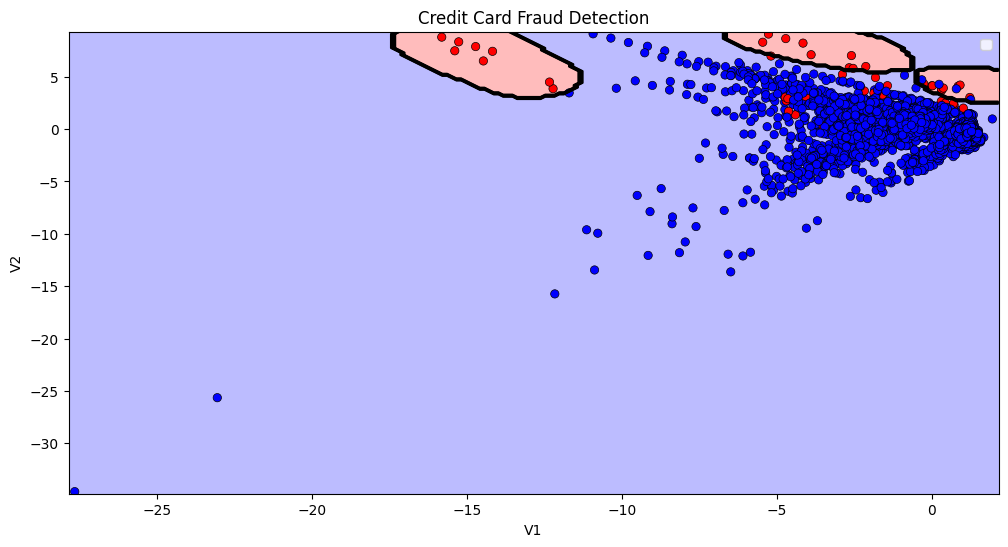

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_2d = X.iloc[:, :2]


X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)


rbf_model_2d = SVC(kernel='rbf')
rbf_model_2d.fit(X_train_2d, y_train_2d)

xx,yy=np.meshgrid(
    np.linspace(X_2d.iloc[:,0].min()-0.2,
    X_2d.iloc[:,0].max()+0.2,
                200
                ),
    np.linspace(X_2d.iloc[:,1].min()-0.2,
                X_2d.iloc[:,1].max()+0.2,
                200
                )
)
grid=np.column_stack((xx.ravel(),yy.ravel()))
pred=rbf_model_2d.predict(grid).reshape(xx.shape)
plt.figure(figsize=(12,6))
plt.contourf(
     xx,
    yy,
    pred,
    alpha=0.3,
    cmap='bwr'
)
plt.contour(
    xx,
    yy,
    pred,
    colors='black'
)
sns.scatterplot(
    x=X_2d.iloc[:,0],
    y=X_2d.iloc[:,1],
    c=y,
    cmap='bwr',
    edgecolors='k'
)
plt.title('Credit Card Fraud Detection')
plt.legend()
plt.show()

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("creditcard.csv")

# =========================
# 3. FEATURES & TARGET
# =========================
X = df.drop("Class", axis=1)
y = df["Class"]

# Drop rows where y is NaN (which would also affect X)
nan_indices = y.isnull()
if nan_indices.any():
    print(f"Dropping {nan_indices.sum()} rows with NaN values in the target variable.")
    X = X[~nan_indices]
    y = y[~nan_indices]

# =========================
# 4. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. SCALING (IMPORTANT FOR SVM)S
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 6. HANDLE CLASS IMBALANCE
# =========================
model = SVC(
    kernel="rbf",
    class_weight="balanced",   # VERY IMPORTANT FOR FRAUD DATA
    probability=True
)

# =========================
# 7. TRAIN MODEL
# =========================
model.fit(X_train_scaled, y_train)

# =========================
# 8. PREDICTIONS
# =========================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# =========================
# 9. EVALUATION
# =========================
print("CONFUSION MATRIX:\n", confusion_matrix(y_test, y_pred))
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred))

print("\nROC-AUC SCORE:", roc_auc_score(y_test, y_prob))

Dropping 1 rows with NaN values in the target variable.
CONFUSION MATRIX:
 [[6330    6]
 [   3   17]]

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6336
         1.0       0.74      0.85      0.79        20

    accuracy                           1.00      6356
   macro avg       0.87      0.92      0.89      6356
weighted avg       1.00      1.00      1.00      6356


ROC-AUC SCORE: 0.960858585858586


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics  import accuracy_score

In [ ]:
svm_baseline=SVC(kernel='rbf',C=10)  # Weak Regularzition
svm_baseline.fit(X_train,y_train)
y_pred_baseline=svm_baseline.predict(X_test)
accuracy_baseline=accuracy_score(y_test,y_pred_baseline)
print(f"Baseline Accuracy : {accuracy_baseline}")

Baseline Accuracy : 0.9968533668974198


In [ ]:
pca=PCA(n_components=10)
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)
svm_pca=SVC(kernel='rbf',C=10)
svm_pca.fit(X_train_pca,y_train)
y_pred_pca=svm_pca.predict(X_test_pca)
accuracy_pca=accuracy_score(y_test,y_pred_pca)
print(f"PCA Accuracy : {accuracy_pca}")

PCA Accuracy : 0.9968533668974198


In [ ]:
selector=SelectKBest(score_func=f_classif,k=20)
X_train_selected=selector.fit_transform(X_train,y_train)
X_test_selected=selector.transform(X_test)
svm_selected=SVC(kernel='rbf',C=10)
svm_selected.fit(X_train_selected,y_train)
y_pred_selected=svm_selected.predict(X_test_selected)
accuracy_selected=accuracy_score(y_test,y_pred_selected)
print(f"Selected Features Accuracy : {accuracy_selected}")


Selected Features Accuracy : 0.9992133417243549


In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.85


In [ ]:
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)

In [ ]:
y_prob

array([8.42315161e-07, 1.81294167e-06, 2.10189540e-04, ...,
       5.63838940e-04, 2.96269835e-05, 2.31764524e-05])

In [ ]:
import pickle

pickle.dump(model, open("svm_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))